DAY 1: DECISION TREE INTUITION

📊 Dataset Info:
  - Samples: 150
  - Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  - Classes: ['setosa' 'versicolor' 'virginica']

📋 First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

📈 Class distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


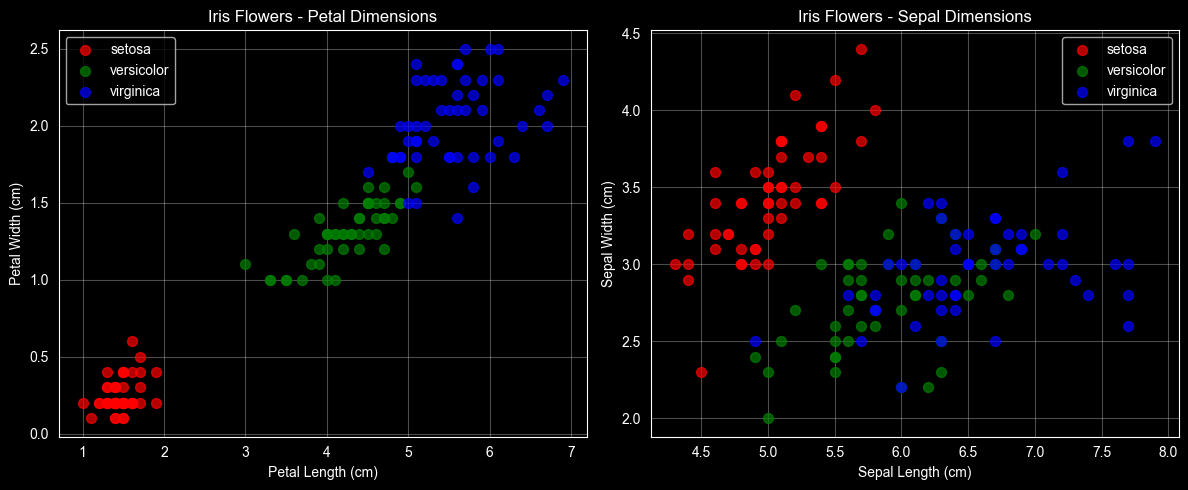


💡 OBSERVATION:
  - Setosa (red) is COMPLETELY SEPARATED by petal dimensions
  - Versicolor (green) and Virginica (blue) overlap slightly
  - A decision tree can easily separate Setosa with ONE question!

📊 Split sizes:
  - Training: 120 samples
  - Testing: 30 samples

✅ Decision Tree Accuracy: 0.9667 (96.7%)


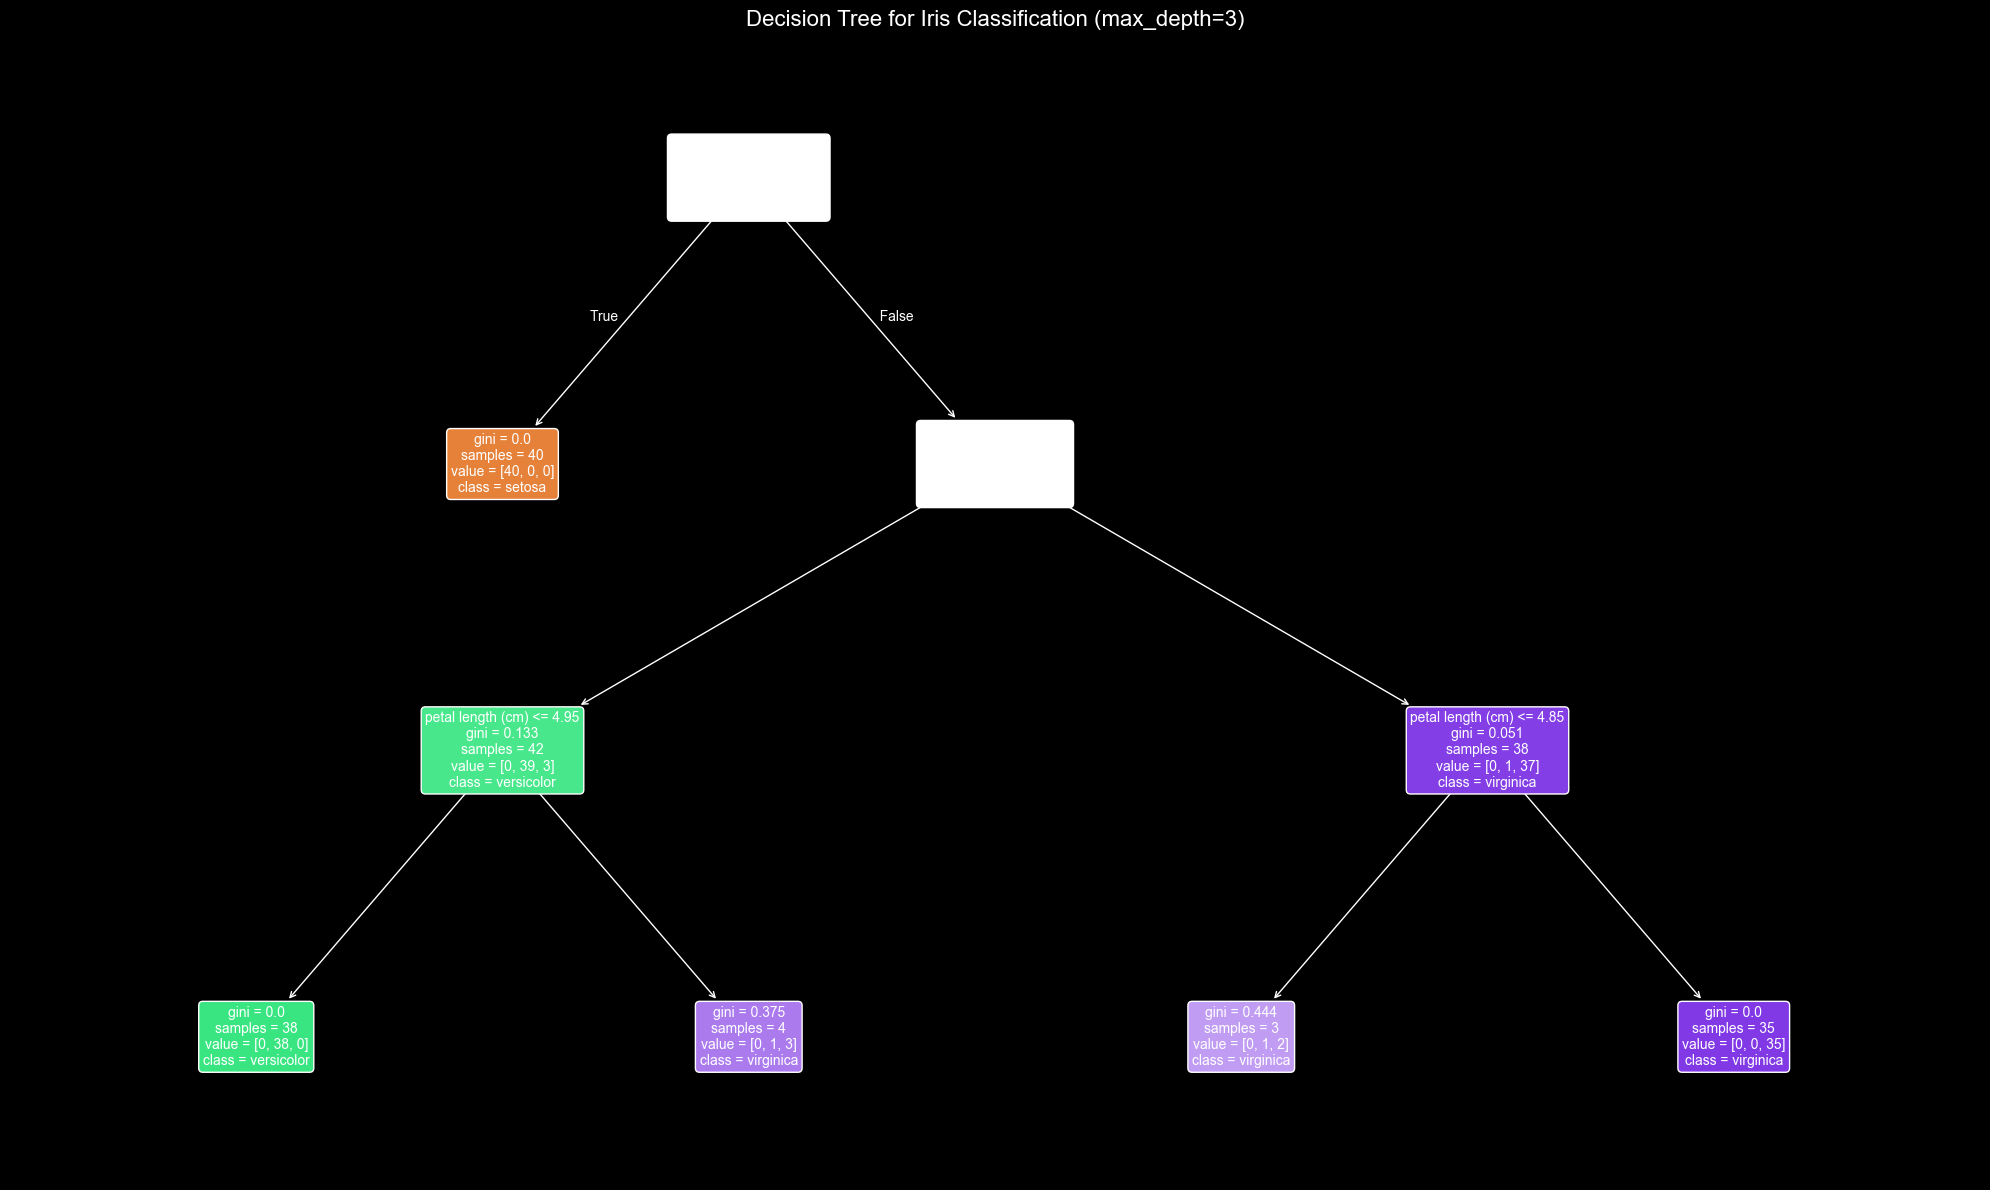


HOW TO READ THIS TREE


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import os
os.makedirs("week4_decision_tree", exist_ok = True)
print("=" * 60)
print("DAY 1: DECISION TREE INTUITION")
print("=" * 60)

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print(f"\n📊 Dataset Info:")
print(f"  - Samples: {X.shape[0]}")
print(f"  - Features: {feature_names}")
print(f"  - Classes: {class_names}")

# Create DataFrame for easier viewing
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📈 Class distribution:")
print(df['species_name'].value_counts())

# Plot petal length vs petal width (the two most important features)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
for i, species in enumerate(class_names):
    mask = df['species'] == i
    plt.scatter(df[mask]['petal length (cm)'], df[mask]['petal width (cm)'],
                c=colors[i], label=species, alpha=0.7, s=50)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Flowers - Petal Dimensions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i, species in enumerate(class_names):
    mask = df['species'] == i
    plt.scatter(df[mask]['sepal length (cm)'], df[mask]['sepal width (cm)'],
                c=colors[i], label=species, alpha=0.7, s=50)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Flowers - Sepal Dimensions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 OBSERVATION:")
print("  - Setosa (red) is COMPLETELY SEPARATED by petal dimensions")
print("  - Versicolor (green) and Virginica (blue) overlap slightly")
print("  - A decision tree can easily separate Setosa with ONE question!")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Split sizes:")
print(f"  - Training: {X_train.shape[0]} samples")
print(f"  - Testing: {X_test.shape[0]} samples")

# Train Decision Tree (limit depth to 3 so it's readable)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Predict
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Decision Tree Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

# Plot the decision tree
plt.figure(figsize=(20, 12))
plot_tree(tree,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,  # Colors the nodes
          rounded=True,  # Rounded corners
          fontsize=10,
          impurity=True)  # Show Gini impurity
plt.title("Decision Tree for Iris Classification (max_depth=3)", fontsize=16)
plt.tight_layout()
plt.savefig('week4_decision_tree/iris_tree.png', dpi=150, bbox_inches='tight')
plt.show()





In [11]:
print("\n📖 TREE EXPLANATION:")

# Get tree information
n_nodes = tree.tree_.node_count
children_left = tree.tree_.children_left
children_right = tree.tree_.children_right
feature = tree.tree_.feature
threshold = tree.tree_.threshold
value = tree.tree_.value

print(f"\n🌳 This tree has {n_nodes} nodes")

# Explain root node
root_feature = feature_names[feature[0]]
root_threshold = threshold[0]
print(f"\n🔵 ROOT NODE (Top):")
print(f"   Question: Is '{root_feature}' ≤ {root_threshold:.2f} cm?")

# Explain the left branch (Setosa)
print(f"\n🟢 LEFT BRANCH (YES):")
print(f"   - Goes to pure Setosa node (Gini = 0)")
print(f"   - All {int(value[1][0][0])} samples are Setosa")

# Explain the right branch
print(f"\n🔴 RIGHT BRANCH (NO):")
print(f"   - Mix of Versicolor and Virginica")
print(f"   - Needs more questions to separate")


📖 TREE EXPLANATION:

🌳 This tree has 9 nodes

🔵 ROOT NODE (Top):
   Question: Is 'petal length (cm)' ≤ 2.45 cm?

🟢 LEFT BRANCH (YES):
   - Goes to pure Setosa node (Gini = 0)
   - All 1 samples are Setosa

🔴 RIGHT BRANCH (NO):
   - Mix of Versicolor and Virginica
   - Needs more questions to separate


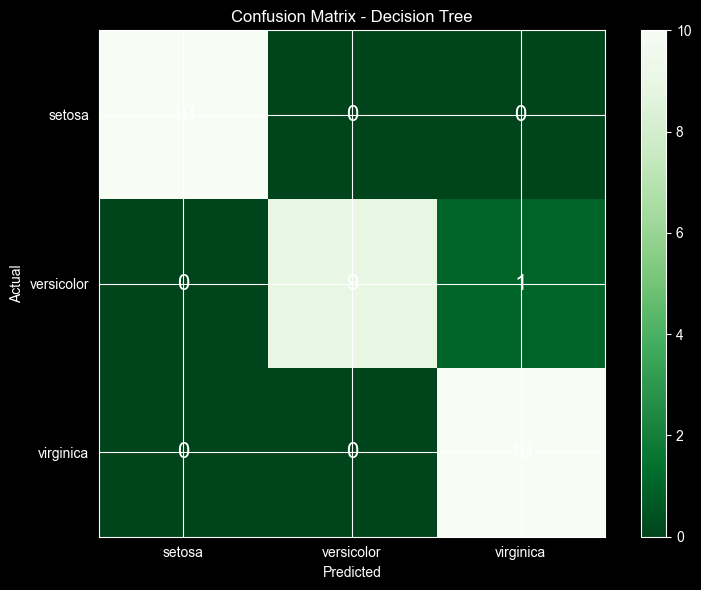


✅ Confusion Matrix:
   - Setosa: 10/10 correct
   - Versicolor: 9/10 correct
   - Virginica: 10/10 correct


In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Greens_r')
plt.title('Confusion Matrix - Decision Tree')
plt.colorbar()
plt.xticks([0, 1, 2], class_names)
plt.yticks([0, 1, 2], class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Add numbers
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16)

plt.tight_layout()
plt.show()

print(f"\n✅ Confusion Matrix:")
print(f"   - Setosa: {cm[0,0]}/{np.sum(y_test==0)} correct")
print(f"   - Versicolor: {cm[1,1]}/{np.sum(y_test==1)} correct")
print(f"   - Virginica: {cm[2,2]}/{np.sum(y_test==2)} correct")